In [ ]:
# =========================================================
# 1. IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

joblib.dump(best_model, "model.pkl")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set_style("whitegrid")

In [ ]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

df = pd.read_csv("data_banjir_combine_final.csv")

# Drop rows with any missing values
df.dropna(inplace=True)

# Convert 'year', 'month', and 'banjir' to integer type
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)
df['banjir'] = df['banjir'].astype(int)

print("Ukuran Dataset:")
print(df.shape)

print("\n5 Data Pertama:")
print(df.head())

print("\nInfo Dataset:")
print(df.info())

print("\nMissing Value:")
print(df.isnull().sum())

Ukuran Dataset:
(7743, 17)

5 Data Pertama:
  NAME_2         NAME_3  avg_rainfall  max_rainfall  avg_temperature  \
0  bogor  babakanmadang        64.775       124.032            28.76   
1  bogor     bojonggede        68.241       128.949            32.89   
2  bogor       caringin        56.423        92.324            29.93   
3  bogor          cariu        60.034        98.129            30.02   
4  bogor        ciampea        66.380       133.877            30.27   

   elevation landcover_class   ndvi  slope  soil_moisture  year  month  \
0    501.913      Tree cover  0.564  5.001         39.583  2020      1   
1    133.589        Built-up  0.429  0.293         40.414  2020      1   
2    765.651      Tree cover  0.513  4.954         39.662  2020      1   
3    143.845      Tree cover  0.652  2.107         39.014  2020      1   
4    212.619      Tree cover  0.569  1.340         39.658  2020      1   

   banjir     lat      long                  map_image   NAME_3_clean  
0     

In [ ]:
# =========================================================
# 3. EDA (EXPLORATORY DATA ANALYSIS)
# =========================================================

print("\nStatistik Deskriptif")
print(df.describe())


Statistik Deskriptif
       avg_rainfall  max_rainfall  avg_temperature    elevation         ndvi  \
count   7744.000000   7744.000000      7744.000000  7744.000000  7744.000000   
mean      40.618804     79.557530        34.565793   113.242384     0.419084   
std       22.807612     41.794469         4.168391   211.829869     0.161022   
min        1.938000      6.025000        17.130000     1.597000     0.082000   
25%       22.833750     49.721250        31.477500    10.530000     0.293000   
50%       36.148000     71.986500        35.260000    27.206000     0.410000   
75%       54.020500    101.878000        37.910000    89.403000     0.529250   
max      146.439000    386.707000        43.830000  1216.752000     0.840000   

             slope  soil_moisture         year        month       banjir  \
count  7744.000000    7743.000000  7743.000000  7743.000000  7743.000000   
mean      0.831024      37.704709  2021.298334     6.078264     0.096862   
std       1.664579       2.33

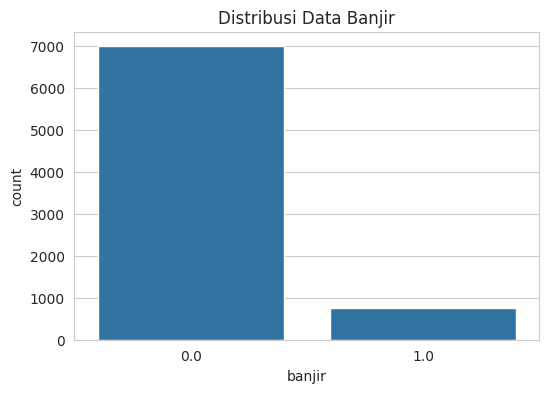

In [ ]:
# =========================================================
# VISUALISASI 1
# DISTRIBUSI KELAS BANJIR
# =========================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='banjir')
plt.title('Distribusi Data Banjir')
plt.show()

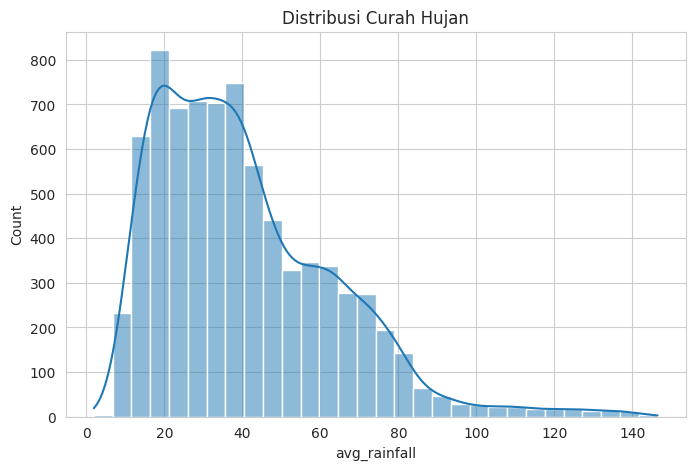

In [ ]:
# =========================================================
# VISUALISASI 2
# DISTRIBUSI CURAH HUJAN
# =========================================================

plt.figure(figsize=(8,5))
sns.histplot(df['avg_rainfall'], bins=30, kde=True)
plt.title('Distribusi Curah Hujan')
plt.show()

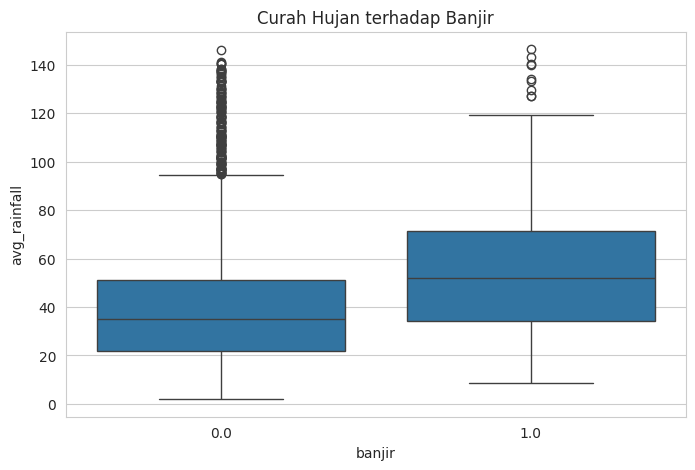

In [ ]:
# =========================================================
# VISUALISASI 3
# CURAH HUJAN VS BANJIR
# =========================================================

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='banjir',
    y='avg_rainfall'
)
plt.title('Curah Hujan terhadap Banjir')
plt.show()

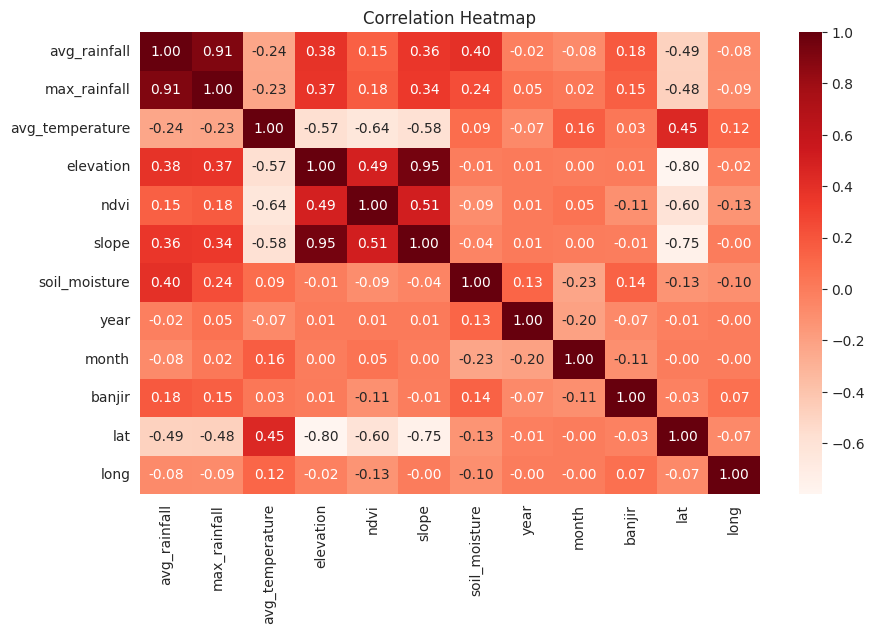

In [ ]:
# =========================================================
# VISUALISASI 4
# HEATMAP KORELASI
# =========================================================

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# =========================================================
# 4. PREPROCESSING
# =========================================================

# First, select all numeric columns from df
numeric_cols_df = df.select_dtypes(include=np.number)

# Then, drop the target variable 'banjir' from these numeric columns to form X
X = numeric_cols_df.drop("banjir", axis=1)
y = df["banjir"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# =========================================================
# 5. TRAINING MODEL
# =========================================================

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")


Logistic Regression
Accuracy : 0.9006

Random Forest
Accuracy : 0.9187

Gradient Boosting
Accuracy : 0.9135


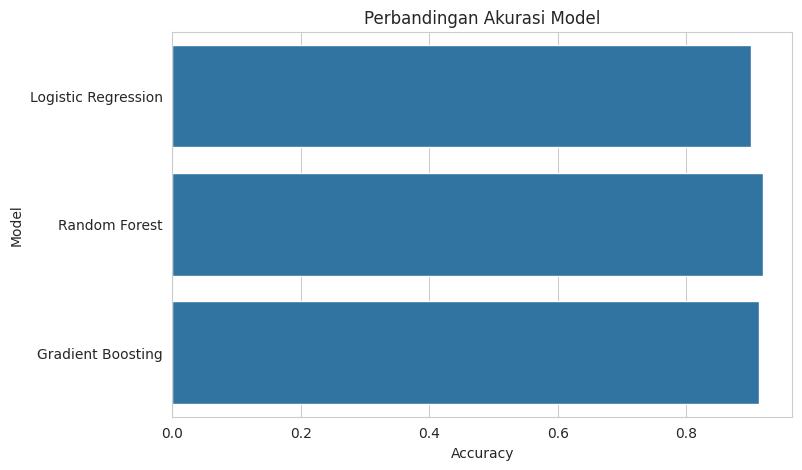

                 Model  Accuracy
1        Random Forest  0.918657
2    Gradient Boosting  0.913493
0  Logistic Regression  0.900581


In [ ]:
# =========================================================
# 6. PERBANDINGAN MODEL
# =========================================================

df_results = pd.DataFrame(results)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_results,
    x="Accuracy",
    y="Model"
)

plt.title("Perbandingan Akurasi Model")
plt.show()

print(df_results.sort_values(
    by="Accuracy",
    ascending=False
))

In [ ]:
# =========================================================
# 7. MODEL TERBAIK
# =========================================================

best_model = RandomForestClassifier(
    random_state=42
)

best_model.fit(
    X_train_scaled,
    y_train
)

y_pred = best_model.predict(
    X_test_scaled
)

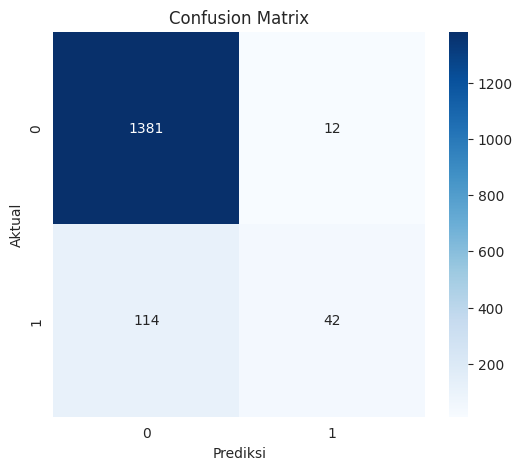

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      1393
           1       0.78      0.27      0.40       156

    accuracy                           0.92      1549
   macro avg       0.85      0.63      0.68      1549
weighted avg       0.91      0.92      0.90      1549



In [ ]:
# =========================================================
# 8. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

print(classification_report(
    y_test,
    y_pred
))

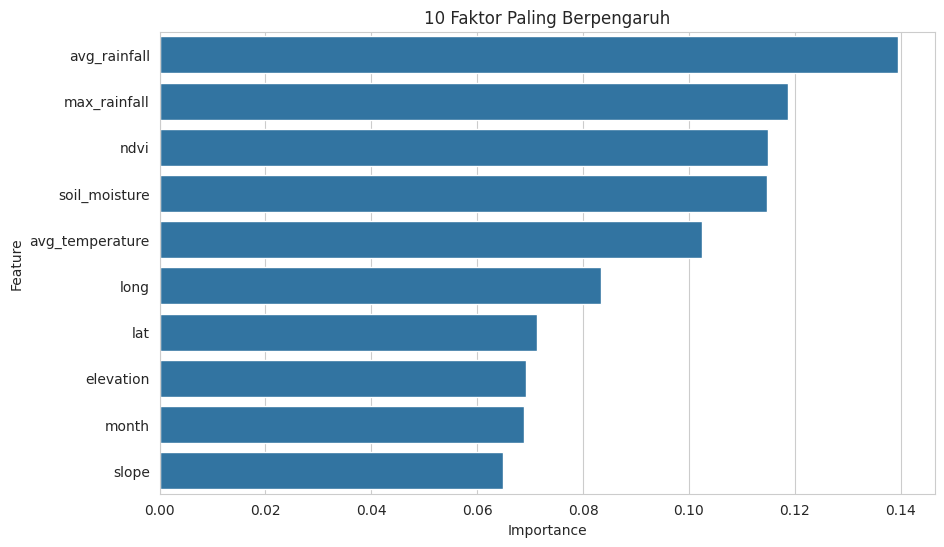

            Feature  Importance
0      avg_rainfall    0.139429
1      max_rainfall    0.118756
4              ndvi    0.114946
6     soil_moisture    0.114745
2   avg_temperature    0.102447
10             long    0.083339
9               lat    0.071398
3         elevation    0.069252
8             month    0.068886
5             slope    0.064863


In [ ]:
# =========================================================
# 9. FEATURE IMPORTANCE
# =========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
        best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "10 Faktor Paling Berpengaruh"
)

plt.show()

print(importance.head(10))

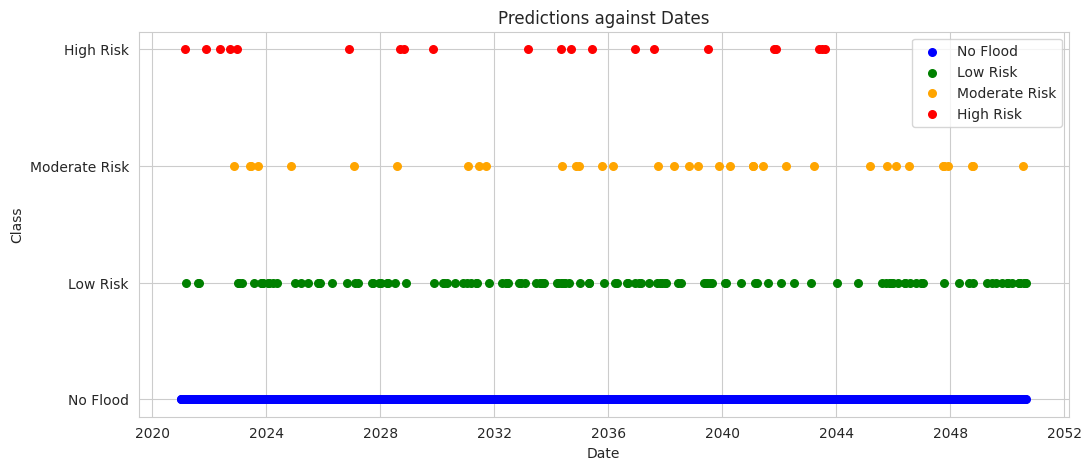

In [ ]:
# Misal hasil prediksi probabilitas
prob = best_model.predict_proba(X_test_scaled)[:,1]

# Kategori risiko
risk = []

for p in prob:
    if p < 0.25:
        risk.append("No Flood")
    elif p < 0.50:
        risk.append("Low Risk")
    elif p < 0.75:
        risk.append("Moderate Risk")
    else:
        risk.append("High Risk")

# Buat tanggal dummy
dates = pd.date_range(
    start="2021-01-01",
    periods=len(prob),
    freq="7D"
)

risk_num = []

for r in risk:
    if r == "No Flood":
        risk_num.append(0)
    elif r == "Low Risk":
        risk_num.append(1)
    elif r == "Moderate Risk":
        risk_num.append(2)
    else:
        risk_num.append(3)

plt.figure(figsize=(12,5))

colors = {
    "No Flood":"blue",
    "Low Risk":"green",
    "Moderate Risk":"orange",
    "High Risk":"red"
}

for r in colors:
    mask = np.array(risk) == r
    plt.scatter(
        dates[mask],
        np.array(risk_num)[mask],
        label=r,
        color=colors[r],
        s=30
    )

plt.yticks(
    [0,1,2,3],
    ["No Flood","Low Risk","Moderate Risk","High Risk"]
)

plt.xlabel("Date")
plt.ylabel("Class")
plt.title("Predictions against Dates")
plt.legend()
plt.show()

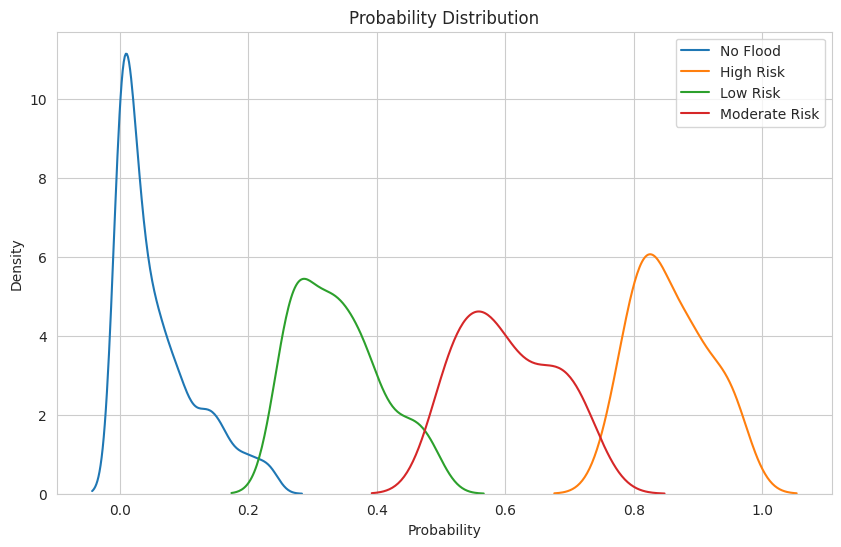

In [ ]:
df_prob = pd.DataFrame({
    "Probability": prob,
    "Risk": risk
})

plt.figure(figsize=(10,6))

for r in df_prob["Risk"].unique():
    sns.kdeplot(
        data=df_prob[df_prob["Risk"] == r],
        x="Probability",
        label=r,
        fill=False
    )

plt.title("Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

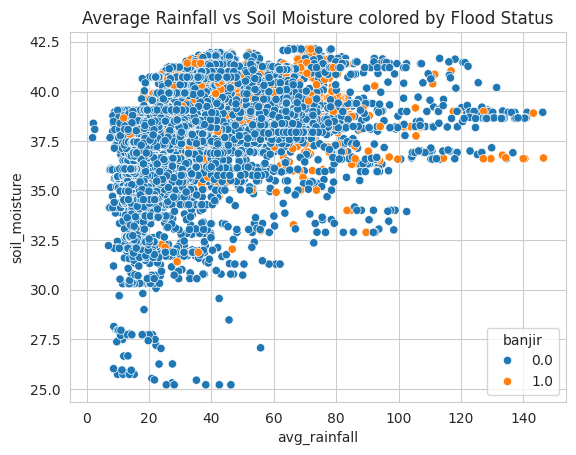

In [ ]:
sns.scatterplot(
    data=df,
    x="avg_rainfall", # Changed from 'Rainfall'
    y="soil_moisture", # Changed from 'StreamFlow'
    hue="banjir" # Changed from 'Flood'
)

plt.title("Average Rainfall vs Soil Moisture colored by Flood Status") # Updated title
plt.show()